# Final Architecture Results — Phase 4 & Best Models

**Focus:** Phase 4 hybrid architecture outcomes + overall best models across all research phases.

Condensed analysis notebook (complementary to `final_analysis_phase5.ipynb`).

## 1. Setup & Data Loading

In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path

import wandb

# Sync W&B offline runs (optional)
print("Syncing W&B offline runs...")
import subprocess
try:
    subprocess.run(["wandb", "sync", "--sync-all"], capture_output=True, timeout=30)
    print("✓ W&B sync complete")
except Exception as e:
    print(f"⚠ W&B sync skipped: {e}")


def find_project_root(start: Path | None = None):
    """Walk upward until the repository root is found."""
    start = start or Path.cwd()
    for candidate in (start, *start.parents):
        if (candidate / "README.md").exists() and (candidate / "results").exists() and (candidate / "models").exists():
            return candidate
    return start


project_root = find_project_root()

PHASE4_DIR = project_root / "results" / "phase_4_compression_and_final_architecture_training"
ALL_PHASES_DIRS = {
    "Phase 1": project_root / "results" / "phase_1_baseline_training",
    "Phase 2": project_root / "results" / "phase_2_kernel_restriction_training",
    "Phase 3": project_root / "results" / "phase_3_compensation_and_hybrids_training",
    "Phase 4": PHASE4_DIR,
}

FIGURES_DIR = project_root / "results" / "figures_generated"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({"font.size": 11})
print("✓ Setup complete")

Syncing W&B offline runs...
✓ W&B sync complete
✓ Setup complete


In [2]:
# Load Phase 4 comparison table
phase4_comp = pd.read_csv(PHASE4_DIR / "final_comparison.csv")
phase4_comp["phase"] = "Phase 4"

# Load all cross-phase comparisons
all_comps = [phase4_comp]
for phase_name, phase_dir in list(ALL_PHASES_DIRS.items())[:-1]:  # Skip Phase 4, already loaded
    csv_path = phase_dir / "final_comparison.csv"
    if csv_path.exists():
        df = pd.read_csv(csv_path)
        df["phase"] = phase_name
        all_comps.append(df)

df_all = pd.concat(all_comps, ignore_index=True)

# Load per-model summaries (Phase 4 only for now)
phase4_summaries = {}
for json_file in sorted(PHASE4_DIR.glob("*_summary.json")):
    if json_file.name != "experiment_summary.json":
        with open(json_file) as f:
            phase4_summaries[json_file.stem] = json.load(f)

print(f"✓ Loaded Phase 4: {len(phase4_comp)} models")
print(f"✓ Loaded all phases: {len(df_all)} model variants")
print(f"✓ Loaded Phase 4 summaries: {len(phase4_summaries)} models")

✓ Loaded Phase 4: 8 models
✓ Loaded all phases: 45 model variants
✓ Loaded Phase 4 summaries: 9 models


## 2. Phase 4 Summary Table

In [3]:
print("Phase 4 — Final Architecture Models (FP32 & INT8 Quantization)")
print("="*80)

phase4_display = phase4_comp[["model", "precision", "top1_%", "top5_%", "loss", "params_M", "size_MB"]].copy()
phase4_display = phase4_display.sort_values(["precision", "top1_%"], ascending=[False, False])

display(phase4_display.reset_index(drop=True))

print("\n📊 Phase 4 Best Models:")
fp32_best = phase4_comp[phase4_comp["precision"] == "FP32"].nlargest(1, "top1_%")
int8_best = phase4_comp[phase4_comp["precision"] == "INT8"].nlargest(1, "top1_%")

if not fp32_best.empty:
    row = fp32_best.iloc[0]
    print(f"  FP32 Best: {row['model']:40s} | {row['top1_%']:6.2f}% top-1 | {row['size_MB']:6.2f} MB")

if not int8_best.empty:
    row = int8_best.iloc[0]
    print(f"  INT8 Best: {row['model']:40s} | {row['top1_%']:6.2f}% top-1 | {row['size_MB']:6.2f} MB")

Phase 4 — Final Architecture Models (FP32 & INT8 Quantization)


,model,precision,top1_%,top5_%,loss,params_M,size_MB
0,alexnet_final_fire_residual_INT8,INT8,49.201027,74.387586,2.153559,0.698664,0.746309
1,alexnet_final_bottleneck_residual_INT8,INT8,45.980674,72.328943,2.280574,0.571304,0.637690
2,alexnet_final_bottleneck_fire_INT8,INT8,44.001037,70.151949,2.381651,0.506408,0.545216
3,alexnet_final_depthwise_fire_INT8,INT8,42.789248,68.953073,2.452214,0.474921,0.509390
4,alexnet_final_fire_residual,FP32,49.793291,74.802184,2.131824,0.698664,8.093657
5,alexnet_final_bottleneck_residual,FP32,45.099601,71.151185,2.338797,0.571304,6.653960
6,alexnet_final_depthwise_fire,FP32,43.455875,69.023257,2.443448,0.474921,5.511263
7,alexnet_final_bottleneck_fire,FP32,42.286080,68.539512,2.490701,0.506408,5.882781



📊 Phase 4 Best Models:
  FP32 Best: alexnet_final_fire_residual              |  49.79% top-1 |   8.09 MB
  INT8 Best: alexnet_final_fire_residual_INT8         |  49.20% top-1 |   0.75 MB


## 3. Phase 4 Visualizations

### 3.1 FP32 vs INT8 Quantization Impact

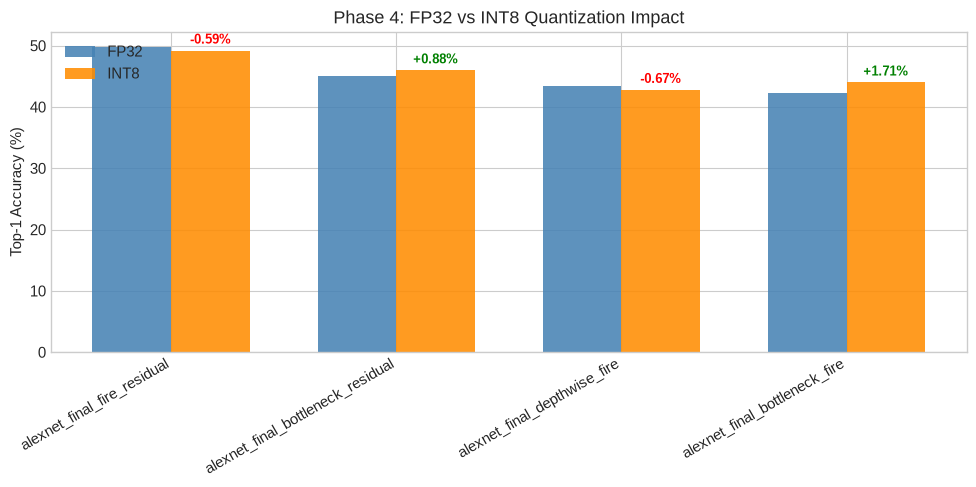

✓ Saved phase4_fp32_vs_int8.png


In [4]:
# Prepare Phase 4 quantization comparison
_df = phase4_comp.copy()
_df["base_model"] = _df["model"].str.replace("_INT8", "", regex=False)

has_both = _df.groupby("base_model")["precision"].apply(
    lambda x: {"FP32", "INT8"}.issubset(set(x))
)
paired = has_both[has_both].index.tolist()

if paired:
    df_paired = _df[_df["base_model"].isin(paired)].copy()
    df_pivot = (
        df_paired
        .pivot_table(index="base_model", columns="precision", values="top1_%")
        .reset_index()
    )
    df_pivot["drop"] = df_pivot["FP32"] - df_pivot["INT8"]
    df_pivot = df_pivot.sort_values("FP32", ascending=False).reset_index(drop=True)

    x = np.arange(len(df_pivot))
    w = 0.35

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.bar(x - w/2, df_pivot["FP32"], w, label="FP32", color="steelblue", alpha=0.87)
    ax.bar(x + w/2, df_pivot["INT8"], w, label="INT8", color="darkorange", alpha=0.87)

    for i, row in df_pivot.iterrows():
        color = "red" if row["drop"] > 0.5 else "green" if row["drop"] < 0 else "gray"
        sign = "-" if row["drop"] > 0 else "+"
        ax.annotate(
            f"{sign}{abs(row['drop']):.2f}%",
            xy=(x[i] + w/2, row["INT8"]),
            xytext=(0, 5), textcoords="offset points",
            ha="center", fontsize=9, color=color, fontweight="bold",
        )

    ax.set_xticks(x)
    ax.set_xticklabels(df_pivot["base_model"], rotation=30, ha="right")
    ax.set_ylabel("Top-1 Accuracy (%)")
    ax.set_title("Phase 4: FP32 vs INT8 Quantization Impact")
    ax.legend()
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "phase4_fp32_vs_int8.png", dpi=150, bbox_inches="tight")
    plt.show()
    print(f"✓ Saved phase4_fp32_vs_int8.png")

### 3.2 Phase 4 Model Efficiency

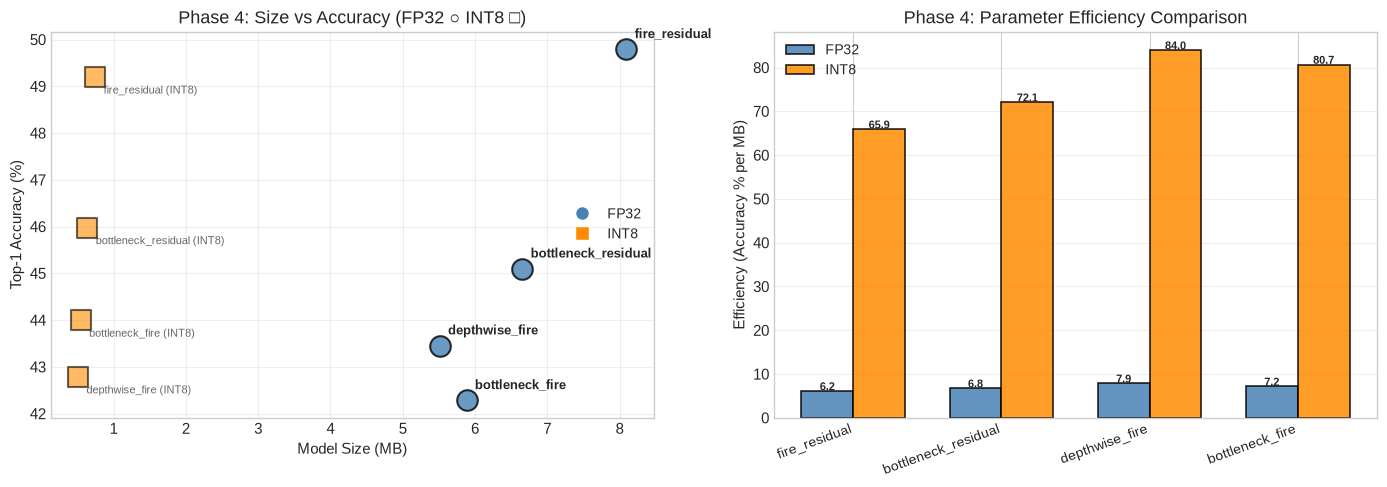

✓ Saved phase4_efficiency.png (FP32 + INT8 comparison)


In [5]:
# Efficiency: accuracy per MB — FP32 vs INT8 comparison
phase4_fp32 = phase4_comp[phase4_comp["precision"] == "FP32"].copy()
phase4_int8 = phase4_comp[phase4_comp["precision"] == "INT8"].copy()

phase4_fp32["efficiency"] = phase4_fp32["top1_%"] / phase4_fp32["size_MB"]
phase4_int8["efficiency"] = phase4_int8["top1_%"] / phase4_int8["size_MB"]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# LEFT: Scatter plot — Size vs Accuracy (FP32 circles, INT8 squares)
for idx, row in phase4_fp32.iterrows():
    ax1.scatter(row["size_MB"], row["top1_%"], s=220, alpha=0.8, 
               edgecolors="black", lw=1.5, color="steelblue", zorder=3)
    model_label = row["model"].replace("alexnet_final_", "")
    ax1.annotate(model_label, 
                 (row["size_MB"], row["top1_%"]),
                 xytext=(6, 8), textcoords="offset points", fontsize=9, fontweight="bold")

for idx, row in phase4_int8.iterrows():
    ax1.scatter(row["size_MB"], row["top1_%"], s=220, alpha=0.6, marker="s",
               edgecolors="black", lw=1.5, color="darkorange", zorder=3)
    model_label = row["model"].replace("_INT8", "").replace("alexnet_final_", "")
    ax1.annotate(f"{model_label} (INT8)", 
                 (row["size_MB"], row["top1_%"]),
                 xytext=(6, -12), textcoords="offset points", fontsize=8, alpha=0.7)

# Add legend patch
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker="o", color="w", markerfacecolor="steelblue", markersize=10, label="FP32"),
    Line2D([0], [0], marker="s", color="w", markerfacecolor="darkorange", markersize=10, label="INT8"),
]
ax1.legend(handles=legend_elements, loc="best", fontsize=10)
ax1.set_xlabel("Model Size (MB)")
ax1.set_ylabel("Top-1 Accuracy (%)")
ax1.set_title("Phase 4: Size vs Accuracy (FP32 ○ INT8 □)")
ax1.grid(True, alpha=0.3)

# RIGHT: Bar chart — Efficiency comparison
model_names = phase4_fp32["model"].str.replace("alexnet_final_", "").values
fp32_effs = phase4_fp32["efficiency"].values

# Match INT8 to FP32 for comparison
int8_effs = []
for fp32_model in phase4_fp32["model"]:
    int8_model = fp32_model + "_INT8"
    match = phase4_int8[phase4_int8["model"] == int8_model]
    if not match.empty:
        int8_effs.append(match.iloc[0]["efficiency"])
    else:
        int8_effs.append(0)

x = np.arange(len(model_names))
w = 0.35

ax2.bar(x - w/2, fp32_effs, w, label="FP32", color="steelblue", alpha=0.85, edgecolor="black", lw=1.2)
ax2.bar(x + w/2, int8_effs, w, label="INT8", color="darkorange", alpha=0.85, edgecolor="black", lw=1.2)

# Add value labels
for i, (fp32, int8) in enumerate(zip(fp32_effs, int8_effs)):
    ax2.text(i - w/2, fp32 + 0.15, f"{fp32:.1f}", ha="center", fontsize=8, fontweight="bold")
    if int8 > 0:
        ax2.text(i + w/2, int8 + 0.15, f"{int8:.1f}", ha="center", fontsize=8, fontweight="bold")

ax2.set_xticks(x)
ax2.set_xticklabels(model_names, rotation=20, ha="right", fontsize=10)
ax2.set_ylabel("Efficiency (Accuracy % per MB)")
ax2.set_title("Phase 4: Parameter Efficiency Comparison")
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3, axis="y")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "phase4_efficiency.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"✓ Saved phase4_efficiency.png (FP32 + INT8 comparison)")

### 3.3 Phase 4 Ablation Summary


📈 Phase 4 Ablation: Hybrid vs Single-Mechanism Parents


,Hybrid Model,Parents,Hybrid Top-1 %,Best Parent Top-1 %,Delta %
0,alexnet_final_bottleneck_fire,Bottleneck + Fire,42.286080,44.622979,-2.336898
1,alexnet_final_fire_residual,Fire + Residual,49.793291,48.012939,1.780352
2,alexnet_final_bottleneck_residual,Bottleneck + Residual,45.099601,48.012939,-2.913338
3,alexnet_final_depthwise_fire,Depthwise-Sep + Fire,43.455875,44.390011,-0.934136


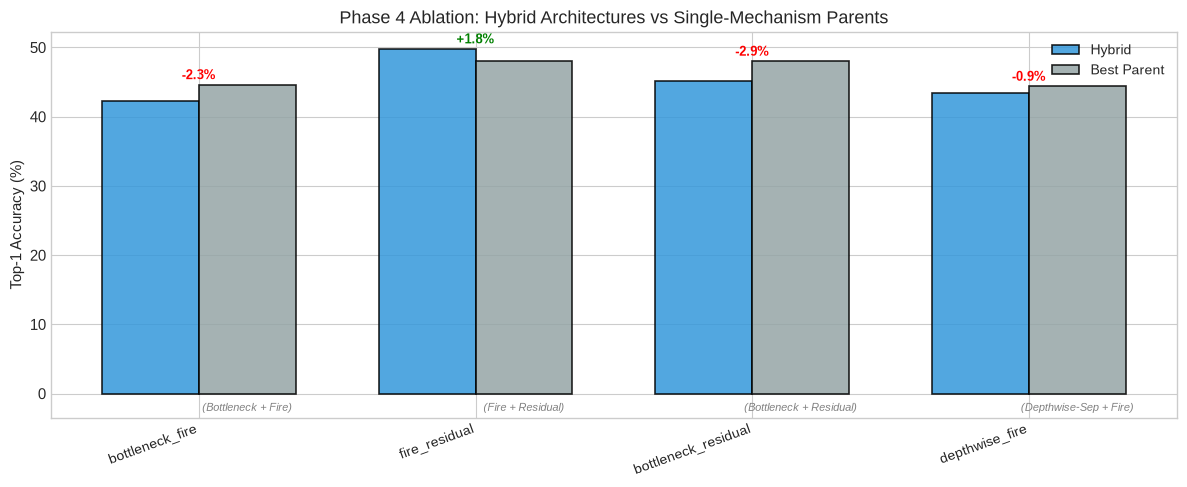

✓ Saved phase4_ablation.png (with parent specifications)


In [6]:
# Load Phase 4 ablation results
ablation_path = PHASE4_DIR / "ablation_results.csv"
if ablation_path.exists():
    ablation = pd.read_csv(ablation_path)
    
    print("\n📈 Phase 4 Ablation: Hybrid vs Single-Mechanism Parents")
    print("="*80)
    
    # Map hybrids to their parents for display
    parent_map = {
        "alexnet_final_bottleneck_fire": ["Bottleneck", "Fire"],
        "alexnet_final_fire_residual": ["Fire", "Residual"],
        "alexnet_final_bottleneck_residual": ["Bottleneck", "Residual"],
        "alexnet_final_depthwise_fire": ["Depthwise-Sep", "Fire"],
    }
    
    display_cols = ["hybrid", "hybrid_top1", "best_parent_top1", "delta_vs_best_parent"]
    ablation_display = ablation[[c for c in display_cols if c in ablation.columns]].copy()
    ablation_display.columns = ["Hybrid Model", "Hybrid Top-1 %", "Best Parent Top-1 %", "Delta %"]
    
    # Add parent info
    ablation_display["Parents"] = ablation["hybrid"].map(lambda x: " + ".join(parent_map.get(x, ["Unknown"])))
    
    display(ablation_display[["Hybrid Model", "Parents", "Hybrid Top-1 %", "Best Parent Top-1 %", "Delta %"]])
    
    # Visualization with parent labels
    fig, ax = plt.subplots(figsize=(12, 5))
    
    x = np.arange(len(ablation))
    w = 0.35
    
    hybrid_names = ablation["hybrid"].str.replace("alexnet_final_", "").values
    ax.bar(x - w/2, ablation["hybrid_top1"], w, label="Hybrid", color="#3498db", alpha=0.85, edgecolor="black", lw=1.2)
    ax.bar(x + w/2, ablation["best_parent_top1"], w, label="Best Parent", color="#95a5a6", alpha=0.85, edgecolor="black", lw=1.2)
    
    # Annotations: delta + parent info
    for i, (idx, row) in enumerate(ablation.iterrows()):
        delta = row["delta_vs_best_parent"]
        color = "green" if delta > 0 else "red"
        sign = "+" if delta > 0 else ""
        
        # Parent names
        parents = parent_map.get(row["hybrid"], ["Unknown"])
        parent_label = " + ".join(parents)
        
        # Delta annotation
        ax.text(x[i], max(row["hybrid_top1"], row["best_parent_top1"]) + 0.8,
                f"{sign}{delta:.1f}%", ha="center", fontsize=9, color=color, fontweight="bold")
        
        # Parent label below x-axis
        ax.text(x[i] + w/2, -2.5, f"({parent_label})", ha="center", fontsize=8, 
               style="italic", color="gray", rotation=0)
    
    ax.set_xticks(x)
    ax.set_xticklabels(hybrid_names, rotation=20, ha="right", fontsize=10)
    ax.set_ylabel("Top-1 Accuracy (%)")
    ax.set_title("Phase 4 Ablation: Hybrid Architectures vs Single-Mechanism Parents")
    ax.set_ylim(bottom=-3.5)
    ax.legend(fontsize=10, loc="upper right")
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "phase4_ablation.png", dpi=150, bbox_inches="tight")
    plt.show()
    print(f"✓ Saved phase4_ablation.png (with parent specifications)")
else:
    print("[skip] ablation_results.csv not found")

## 4. Cross-Phase Best Models

Full cross-phase accuracy-vs-size Pareto frontier: see `final_analysis_phase5.ipynb` §4 (verified to produce an identical frontier from this notebook's data).

In [7]:
# Top 10 models by FP32 accuracy across all phases
df_fp32_all = df_all[df_all["precision"] == "FP32"].copy()
top10 = df_fp32_all.nlargest(10, "top1_%")[["phase", "model", "top1_%", "top5_%", "params_M", "size_MB"]]

print("\n🏆 Top 10 Models — All Phases (FP32)")
print("="*80)
display(top10.reset_index(drop=True))

# Highlight Phase 4 in top 10
phase4_in_top10 = top10[top10["phase"] == "Phase 4"]
if not phase4_in_top10.empty:
    print(f"\n✓ Phase 4 models in top 10: {len(phase4_in_top10)}")
    for _, row in phase4_in_top10.iterrows():
        print(f"  • {row['model']:40s} | {row['top1_%']:6.2f}%")
else:
    print("\n⚠ No Phase 4 models in top 10 by accuracy")


🏆 Top 10 Models — All Phases (FP32)


,phase,model,top1_%,top5_%,params_M,size_MB
0,Phase 1,mobilenetv2,57.995582,81.514984,2.480072,28.751925
1,Phase 1,resnet18_tv,53.913635,77.797484,11.279112,129.208681
2,Phase 1,vgg_style,51.814806,75.881696,2.405288,27.584812
3,Phase 4,alexnet_final_fire_residual,49.793291,74.802184,0.698664,8.093657
4,Phase 3,alexnet_residual,48.012939,73.108339,60.670280,694.414034
5,Phase 2,alexnet_small_kernel,45.836565,71.076936,1.602376,18.353315
6,Phase 2,alexnet_stacked,45.219755,70.960724,60.483976,692.255035
7,Phase 4,alexnet_final_bottleneck_residual,45.099601,71.151185,0.571304,6.653960
8,Phase 3,alexnet_bottleneck,44.622979,71.036339,0.385000,4.491745
9,Phase 3,alexnet_depthwisesep,44.390011,69.445616,0.313641,3.654016



✓ Phase 4 models in top 10: 2
  • alexnet_final_fire_residual              |  49.79%
  • alexnet_final_bottleneck_residual        |  45.10%


## 5. Key Findings & Recommendations

In [8]:
print("\n" + "="*80)
print("RESEARCH HIGHLIGHTS")
print("="*80)

# Best overall (all phases)
best_overall = df_fp32_all.nlargest(1, "top1_%").iloc[0]
print(f"\n🥇 Best Overall Accuracy (All Phases):")
print(f"   {best_overall['model']:40s} [{best_overall['phase']}]")
print(f"   Top-1: {best_overall['top1_%']:.2f}%  |  Params: {best_overall['params_M']:.2f}M  |  Size: {best_overall['size_MB']:.2f} MB")

# Best tiny model (<10 MB)
tiny = df_fp32_all[df_fp32_all["size_MB"] < 10].nlargest(1, "top1_%")
if not tiny.empty:
    row = tiny.iloc[0]
    print(f"\n💎 Best Tiny Model (<10 MB):")
    print(f"   {row['model']:40s} [{row['phase']}]")
    print(f"   Top-1: {row['top1_%']:.2f}%  |  Size: {row['size_MB']:.2f} MB  |  Efficiency: {row['top1_%'] / row['size_MB']:.2f} acc/MB")

# Best efficient (acc/MB)
best_eff = df_fp32_all.copy()
best_eff["eff"] = best_eff["top1_%"] / best_eff["size_MB"]
best_efficient = best_eff.nlargest(1, "eff").iloc[0]
print(f"\n⚡ Most Efficient (Accuracy per MB):")
print(f"   {best_efficient['model']:40s} [{best_efficient['phase']}]")
print(f"   Top-1: {best_efficient['top1_%']:.2f}%  |  Size: {best_efficient['size_MB']:.2f} MB  |  Efficiency: {best_efficient['eff']:.2f} acc/MB")

# Phase 4 summary
print(f"\n📊 Phase 4 Summary:")
print(f"   Models: 4 hybrid architectures")
print(f"   Best FP32: {phase4_fp32.nlargest(1, 'top1_%').iloc[0]['model']:35s} | {phase4_fp32['top1_%'].max():.2f}%")
phase4_int8 = phase4_comp[phase4_comp["precision"] == "INT8"]
if not phase4_int8.empty:
    print(f"   Best INT8: {phase4_int8.nlargest(1, 'top1_%').iloc[0]['model']:35s} | {phase4_int8['top1_%'].max():.2f}%")
    avg_drop = (phase4_fp32['top1_%'].mean() - phase4_int8['top1_%'].mean())
    print(f"   Avg QAT drop: {avg_drop:.2f}% (INT8 quantization robustness)")

print("\n" + "="*80)


RESEARCH HIGHLIGHTS

🥇 Best Overall Accuracy (All Phases):
   mobilenetv2                              [Phase 1]
   Top-1: 58.00%  |  Params: 2.48M  |  Size: 28.75 MB

💎 Best Tiny Model (<10 MB):
   alexnet_final_fire_residual              [Phase 4]
   Top-1: 49.79%  |  Size: 8.09 MB  |  Efficiency: 6.15 acc/MB

⚡ Most Efficient (Accuracy per MB):
   alexnet_depthwisesep                     [Phase 3]
   Top-1: 44.39%  |  Size: 3.65 MB  |  Efficiency: 12.15 acc/MB

📊 Phase 4 Summary:
   Models: 4 hybrid architectures
   Best FP32: alexnet_final_fire_residual         | 49.79%
   Best INT8: alexnet_final_fire_residual_INT8    | 49.20%
   Avg QAT drop: -0.33% (INT8 quantization robustness)



## 6. Export Summary Tables

In [9]:
# Phase 4 + Best models comparison export
summary_export = pd.DataFrame([
    {"category": "Phase 4 Best (FP32)", "model": best_overall["model"], "phase": best_overall["phase"],
     "top1_%": best_overall["top1_%"], "size_MB": best_overall["size_MB"], "params_M": best_overall["params_M"]},
])

if not tiny.empty:
    row = tiny.iloc[0]
    summary_export = pd.concat([
        summary_export,
        pd.DataFrame([{"category": "Best Tiny (<10MB)", "model": row["model"], "phase": row["phase"],
                      "top1_%": row["top1_%"], "size_MB": row["size_MB"], "params_M": row["params_M"]}])
    ], ignore_index=True)

summary_export = pd.concat([
    summary_export,
    pd.DataFrame([{"category": "Most Efficient", "model": best_efficient["model"], "phase": best_efficient["phase"],
                  "top1_%": best_efficient["top1_%"], "size_MB": best_efficient["size_MB"], "params_M": best_efficient["params_M"]}])
], ignore_index=True)

summary_export.to_csv(project_root / "results" / "results_aggregate" / "phase4_best_models.csv", index=False)
print(f"✓ Exported phase4_best_models.csv")
display(summary_export)

✓ Exported phase4_best_models.csv


,category,model,phase,top1_%,size_MB,params_M
0,Phase 4 Best (FP32),mobilenetv2,Phase 1,57.995582,28.751925,2.480072
1,Best Tiny (<10MB),alexnet_final_fire_residual,Phase 4,49.793291,8.093657,0.698664
2,Most Efficient,alexnet_depthwisesep,Phase 3,44.390011,3.654016,0.313641


## 7. Compression Phase 4.1 Results

In [10]:
# Load compression results (5 models × 4 methods: int8, int4_ptq, int4_qat, mixed)
COMPRESSION_DIR = project_root / "results" / "phase_4_compression_and_final_architecture_training"

comp_df = pd.read_csv(COMPRESSION_DIR / "compression_final_comparison.csv")
comp_by_method = pd.read_csv(COMPRESSION_DIR / "compression_by_method.csv")
comp_pareto = pd.read_csv(COMPRESSION_DIR / "pareto_frontier.csv")

print(f"✓ Loaded compression results from {COMPRESSION_DIR.name}")
print(f"  {len(comp_df)} runs = {comp_df['model'].nunique()} models × {comp_df['method'].nunique()} methods")
print(f"  Methods: {', '.join(sorted(comp_df['method'].unique()))}")
print(f"  Pareto frontier: {len(comp_pareto)} optimal points")

✓ Loaded compression results from phase_4_compression_and_final_architecture_training
  31 runs = 5 models × 7 methods
  Methods: binary_qat, int2_qat, int4_ptq, int4_qat, int8, mixed, ternary_qat
  Pareto frontier: 15 optimal points


In [11]:
# Compression matrix — every model × method run
print("\n📦 Compression Phase 4.1 — Model × Method Matrix")
print("="*100)

cols = ["model", "method", "precision", "fp32_baseline_acc", "compressed_top1_acc",
        "acc_drop_pp", "compression_ratio", "compressed_size_mb", "acc_per_mb"]
tbl = comp_df[cols].sort_values(["model", "acc_per_mb"], ascending=[True, False]).copy()
tbl.columns = ["Model", "Method", "Precision", "FP32 Acc %", "Compressed Acc %",
               "Drop pp", "Compression×", "Size MB", "Acc/MB"]
display(tbl.round(2).reset_index(drop=True))

# Best method per model, by accuracy-per-MB
print("\n🏆 Best method per model (by accuracy-per-MB):")
best = comp_df.loc[comp_df.groupby("model")["acc_per_mb"].idxmax()]
for _, r in best.sort_values("acc_per_mb", ascending=False).iterrows():
    print(f"  {r['model']:30s} | {r['method']:9s} | {r['compressed_top1_acc']:5.2f}% "
          f"| {r['compression_ratio']:4.1f}× | {r['acc_per_mb']:6.1f} acc/MB")


📦 Compression Phase 4.1 — Model × Method Matrix


,Model,Method,Precision,FP32 Acc %,Compressed Acc %,Drop pp,Compression×,Size MB,Acc/MB
0,alexnet_bottleneck,ternary_qat,ternary,44.62,31.35,13.27,15.44,0.09,331.93
1,alexnet_bottleneck,binary_qat,binary,44.62,12.62,32.00,29.76,0.05,257.64
2,alexnet_bottleneck,int4_qat,int4,44.62,44.34,0.29,7.87,0.19,239.20
3,alexnet_bottleneck,int2_qat,int2,44.62,20.46,24.16,15.44,0.09,216.62
4,alexnet_bottleneck,mixed,int4/8,44.62,44.61,0.01,6.95,0.21,212.53
5,alexnet_bottleneck,int4_ptq,int4,44.62,35.32,9.30,7.87,0.19,190.58
6,alexnet_bottleneck,int8,int8,44.62,44.24,0.39,3.97,0.37,120.48
7,alexnet_depthwisesep,mixed,int4/8,44.39,44.27,0.12,7.50,0.16,280.48
8,alexnet_depthwisesep,int4_qat,int4,44.39,41.32,3.07,7.81,0.15,272.58
9,alexnet_depthwisesep,ternary_qat,ternary,44.39,15.17,29.22,15.21,0.08,194.79



🏆 Best method per model (by accuracy-per-MB):
  alexnet_bottleneck             | ternary_qat | 31.35% | 15.4× |  331.9 acc/MB
  alexnet_depthwisesep           | mixed     | 44.27% |  7.5× |  280.5 acc/MB
  alexnet_fire                   | ternary_qat | 32.81% | 15.6× |  261.9 acc/MB
  alexnet_final_fire_residual    | ternary_qat | 36.54% | 15.6× |  215.0 acc/MB
  mobilenetv2                    | int8      | 55.41% |  4.0× |   23.4 acc/MB


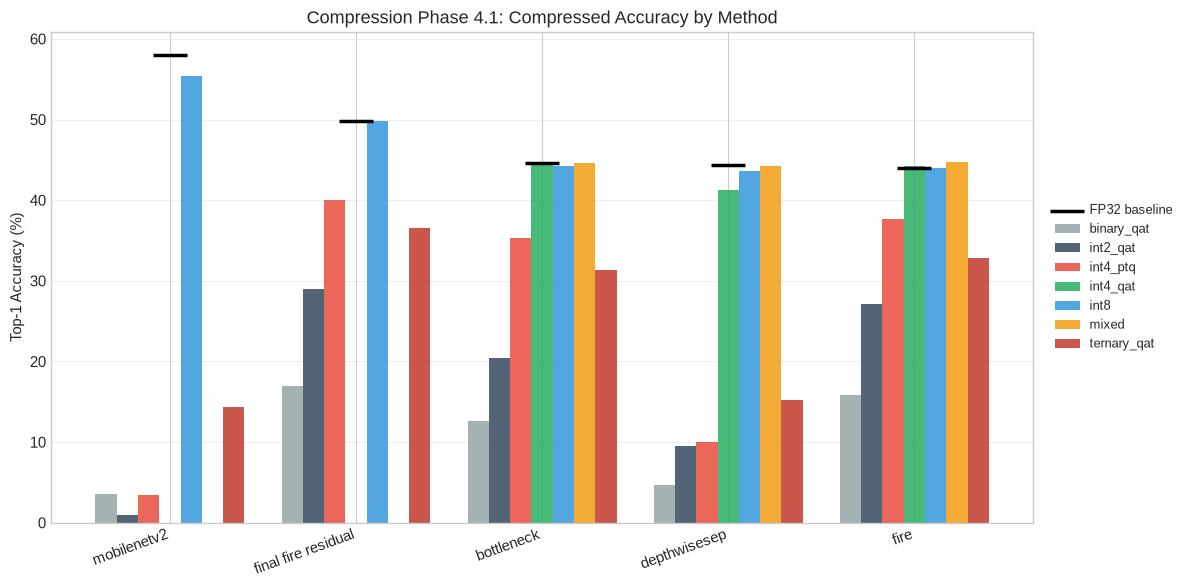

✓ Saved compression_phase4_1_accuracy.png


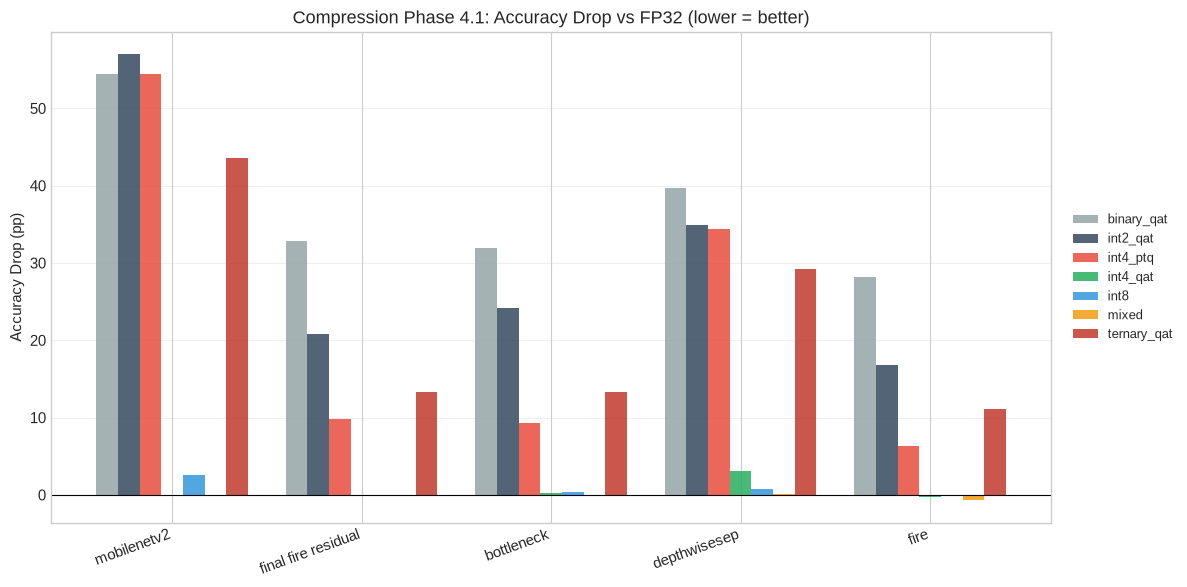

✓ Saved compression_phase4_1_drop.png


/tmp/ipykernel_253862/1964979062.py:137: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(comp_by_method["method"], rotation=20, ha="right")


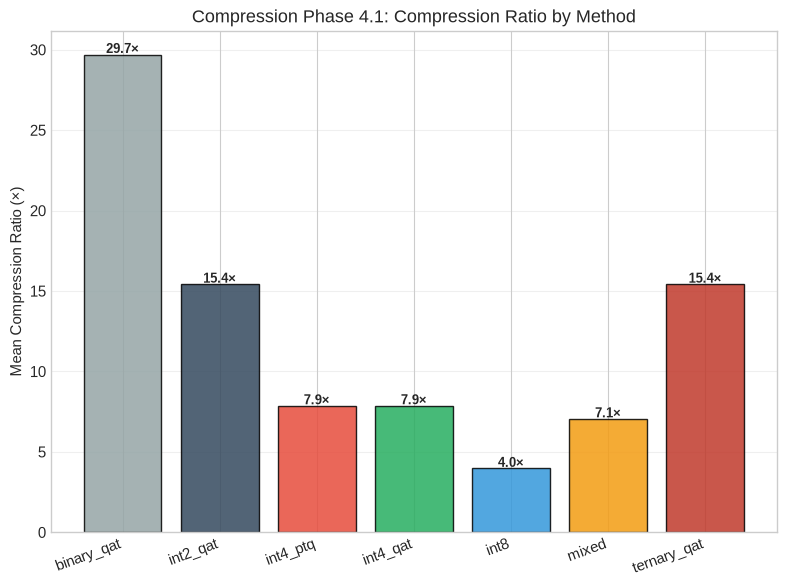

✓ Saved compression_phase4_1_ratio.png


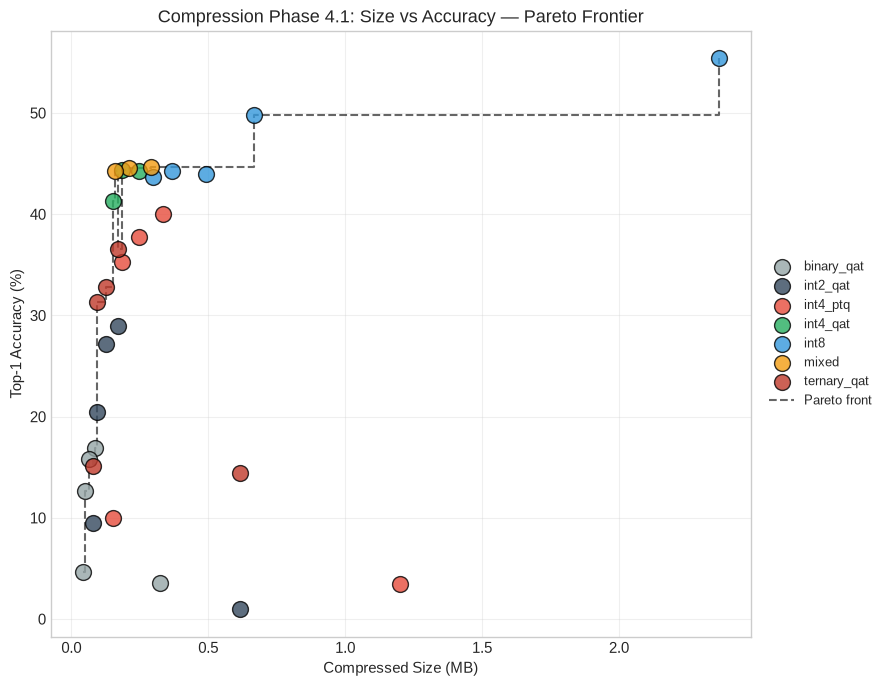

✓ Saved compression_phase4_1_pareto.png


In [12]:
# Compression impact visualization — 4 separate figures
methods = sorted(comp_df["method"].unique())

method_colors = {
    "int8": "#3498db",
    "int4_ptq": "#e74c3c",
    "int4_qat": "#27ae60",
    "mixed": "#f39c12",
    "binary_ptq": "#95a5a6",
    "int2_ptq": "#34495e",
    "ternary_ptq": "#c0392b",
    "binary_qat": "#95a5a6",
    "int2_qat": "#34495e",
    "ternary_qat": "#c0392b",
}

# Assign colors automatically to any methods not explicitly defined
default_colors = plt.cm.tab20(np.linspace(0, 1, len(methods)))
for i, m in enumerate(methods):
    method_colors.setdefault(m, default_colors[i])

# Order models by FP32 baseline accuracy (descending)
models = (
    comp_df.groupby("model")["fp32_baseline_acc"]
    .first()
    .sort_values(ascending=False)
    .index.tolist()
)

short = lambda m: m.replace("alexnet_", "").replace("_", " ")

x = np.arange(len(models))
w = 0.8 / len(methods)

# 1. Compressed accuracy by model & method
fig, ax = plt.subplots(figsize=(12, 6))
acc_piv = (
    comp_df.pivot_table(
        index="model",
        columns="method",
        values="compressed_top1_acc",
    )
    .reindex(models)[methods]
)

for i, meth in enumerate(methods):
    # fillna(0) prevents NaN bars from misaligning the chart
    values = acc_piv[meth].fillna(0)
    ax.bar(
        x + i * w - 0.4 + w / 2,
        values,
        w,
        label=meth,
        color=method_colors[meth],
        alpha=0.85,
    )

base = comp_df.groupby("model")["fp32_baseline_acc"].first().reindex(models)
ax.scatter(
    x,
    base,
    marker="_",
    s=600,
    color="black",
    lw=2.5,
    zorder=5,
    label="FP32 baseline",
)

ax.set_xticks(x)
ax.set_xticklabels([short(m) for m in models], rotation=20, ha="right")
ax.set_ylabel("Top-1 Accuracy (%)")
ax.set_title("Compression Phase 4.1: Compressed Accuracy by Method")
ax.legend(fontsize=9, loc="center left", bbox_to_anchor=(1.01, 0.5))
ax.grid(True, alpha=0.3, axis="y")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "compression_phase4_1_accuracy.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ Saved compression_phase4_1_accuracy.png")

# 2. Accuracy drop
fig, ax = plt.subplots(figsize=(12, 6))
drop_piv = (
    comp_df.pivot_table(
        index="model",
        columns="method",
        values="acc_drop_pp",
    )
    .reindex(models)[methods]
)

for i, meth in enumerate(methods):
    # fillna(0) prevents NaN bars from misaligning the chart
    values = drop_piv[meth].fillna(0)
    ax.bar(
        x + i * w - 0.4 + w / 2,
        values,
        w,
        label=meth,
        color=method_colors[meth],
        alpha=0.85,
    )

ax.axhline(0, color="black", lw=0.8)
ax.set_xticks(x)
ax.set_xticklabels([short(m) for m in models], rotation=20, ha="right")
ax.set_ylabel("Accuracy Drop (pp)")
ax.set_title("Compression Phase 4.1: Accuracy Drop vs FP32 (lower = better)")
ax.legend(fontsize=9, loc="center left", bbox_to_anchor=(1.01, 0.5))
ax.grid(True, alpha=0.3, axis="y")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "compression_phase4_1_drop.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ Saved compression_phase4_1_drop.png")

# 3. Mean compression ratio
fig, ax = plt.subplots(figsize=(8, 6))
ax.bar(
    comp_by_method["method"],
    comp_by_method["mean_ratio"],
    color=[method_colors[m] for m in comp_by_method["method"]],
    alpha=0.85,
    edgecolor="black",
    linewidth=1,
)

for i, r in comp_by_method.reset_index(drop=True).iterrows():
    ax.text(
        i,
        r["mean_ratio"] + 0.1,
        f"{r['mean_ratio']:.1f}×",
        ha="center",
        fontsize=9,
        fontweight="bold",
    )

ax.set_xticklabels(comp_by_method["method"], rotation=20, ha="right")
ax.set_ylabel("Mean Compression Ratio (×)")
ax.set_title("Compression Phase 4.1: Compression Ratio by Method")
ax.grid(True, alpha=0.3, axis="y")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "compression_phase4_1_ratio.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ Saved compression_phase4_1_ratio.png")

# 4. Size vs accuracy (Pareto)
fig, ax = plt.subplots(figsize=(9, 7))

for meth in methods:
    sub = comp_df[comp_df["method"] == meth]
    ax.scatter(
        sub["compressed_size_mb"],
        sub["compressed_top1_acc"],
        s=130,
        alpha=0.8,
        color=method_colors[meth],
        edgecolors="black",
        linewidth=1,
        label=meth,
        zorder=3,
    )

pf = comp_pareto.sort_values("compressed_size_mb")
ax.step(
    pf["compressed_size_mb"],
    pf["compressed_top1_acc"],
    where="post",
    color="black",
    linestyle="--",
    linewidth=1.5,
    alpha=0.6,
    label="Pareto front",
    zorder=2,
)

ax.set_xlabel("Compressed Size (MB)")
ax.set_ylabel("Top-1 Accuracy (%)")
ax.set_title("Compression Phase 4.1: Size vs Accuracy — Pareto Frontier")
ax.legend(fontsize=9, loc="center left", bbox_to_anchor=(1.01, 0.5))
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "compression_phase4_1_pareto.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ Saved compression_phase4_1_pareto.png")


📊 Compression Methods Breakdown (mean across models)


,Method,Mean Top-1 %,Mean Drop pp,Mean Ratio ×,Mean Acc/MB,N models
0,binary_qat,10.73,37.43,29.70,164.85,5
1,int2_qat,17.40,30.75,15.42,145.44,5
2,int4_ptq,25.31,22.85,7.86,106.21,5
3,int4_qat,43.31,1.02,7.86,230.17,3
4,int8,47.40,0.76,3.97,90.76,5
5,mixed,44.52,-0.19,7.05,215.31,3
6,ternary_qat,26.06,22.10,15.42,205.41,5


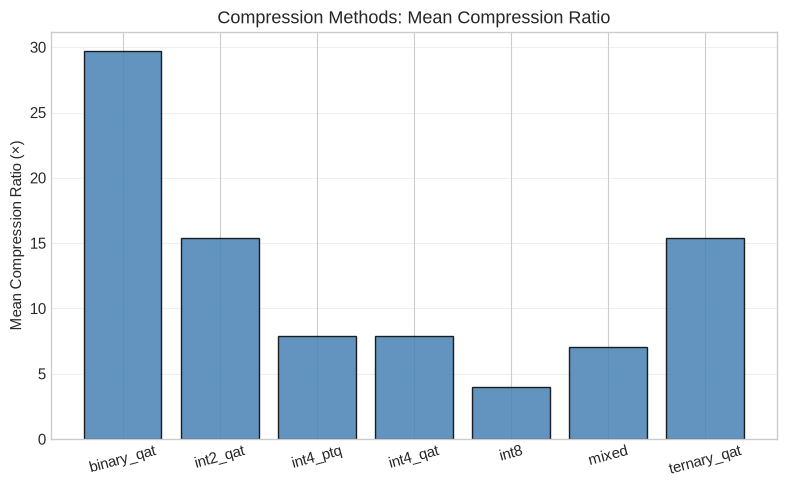

✓ Saved compression_methods_ratio.png


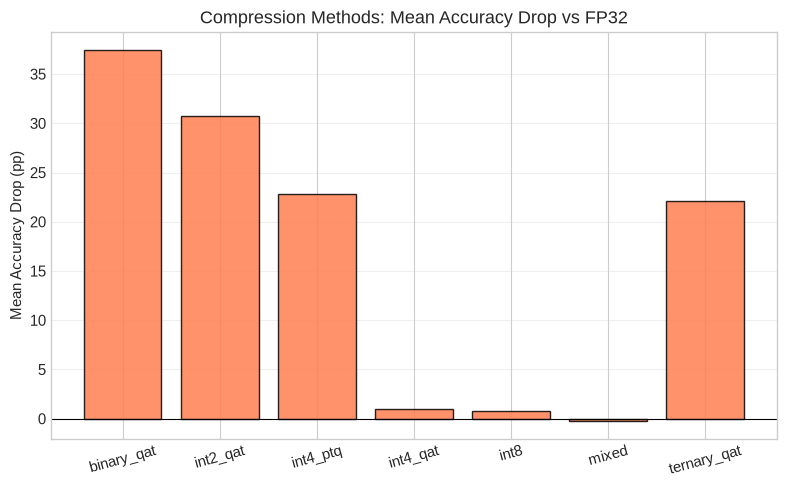

✓ Saved compression_methods_drop.png


In [13]:
# Compression methods breakdown (aggregated across models) — 2 separate figures
print("\n📊 Compression Methods Breakdown (mean across models)")
print("="*100)
disp = comp_by_method.copy()
disp.columns = ["Method", "Mean Top-1 %", "Mean Drop pp", "Mean Ratio ×", "Mean Acc/MB", "N models"]
display(disp.round(2))

x = np.arange(len(comp_by_method))

# 1. Mean compression ratio
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(x, comp_by_method["mean_ratio"], color="steelblue", alpha=0.85, edgecolor="black", lw=1)
ax.set_xticks(x); ax.set_xticklabels(comp_by_method["method"], rotation=15)
ax.set_ylabel("Mean Compression Ratio (×)")
ax.set_title("Compression Methods: Mean Compression Ratio")
ax.grid(True, alpha=0.3, axis="y")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "compression_methods_ratio.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ Saved compression_methods_ratio.png")

# 2. Mean accuracy drop
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(x, comp_by_method["mean_drop_pp"], color="coral", alpha=0.85, edgecolor="black", lw=1)
ax.axhline(0, color="black", lw=0.8)
ax.set_xticks(x); ax.set_xticklabels(comp_by_method["method"], rotation=15)
ax.set_ylabel("Mean Accuracy Drop (pp)")
ax.set_title("Compression Methods: Mean Accuracy Drop vs FP32")
ax.grid(True, alpha=0.3, axis="y")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "compression_methods_drop.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ Saved compression_methods_drop.png")

### 7.4 Accuracy vs Size (Compression Trajectory)

/tmp/ipykernel_253862/127766865.py:36: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_253862/127766865.py:37: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Liberation Sans.
  plt.savefig(FIGURES_DIR / "compression_phase4_1_accuracy_vs_size.png", dpi=150, bbox_inches="tight")
/home/rafael/Documents/dnn_study/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)


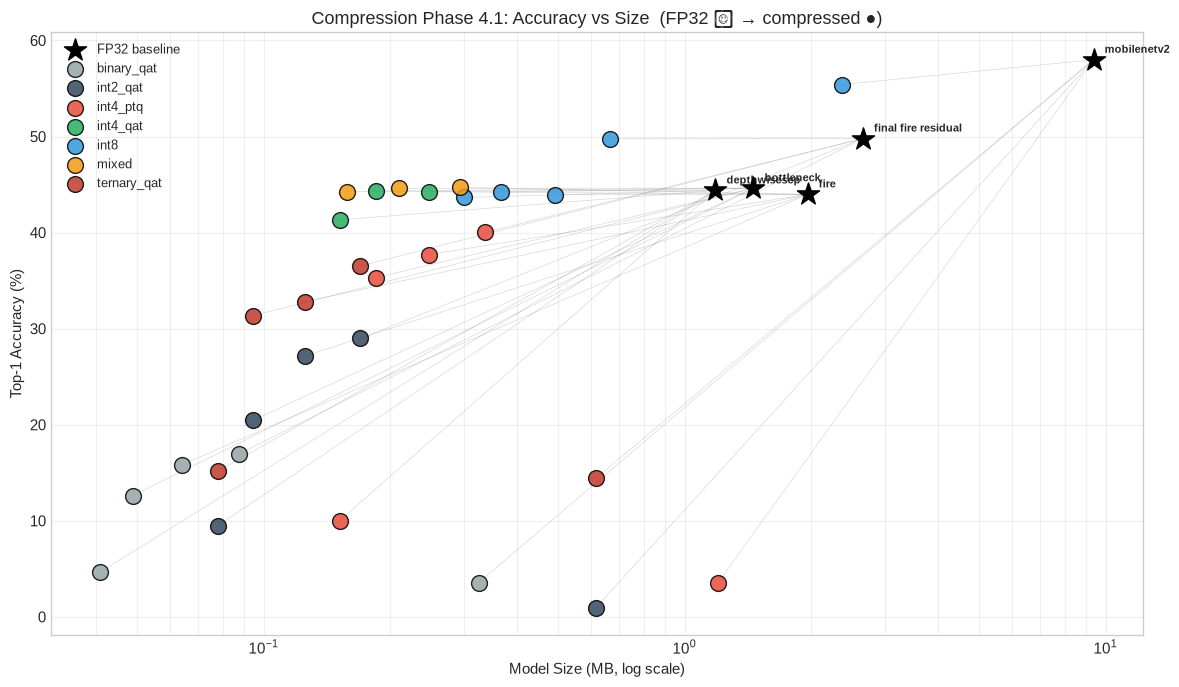

✓ Saved compression_phase4_1_accuracy_vs_size.png


In [14]:
# Accuracy vs Size — FP32 baselines → compressed variants
fig, ax = plt.subplots(figsize=(12, 7))

# method_colors / methods / short already defined above

# FP32 baseline (one point per model)
base = comp_df.groupby("model").agg(
    size=("fp32_size_mb", "first"), acc=("fp32_baseline_acc", "first")).reset_index()
base_map = base.set_index("model")

# Faint line from each FP32 baseline to its compressed variants (compression trajectory)
for _, r in comp_df.iterrows():
    b = base_map.loc[r["model"]]
    ax.plot([b["size"], r["compressed_size_mb"]], [b["acc"], r["compressed_top1_acc"]],
            color="gray", lw=0.5, alpha=0.3, zorder=1)

# FP32 baselines
ax.scatter(base["size"], base["acc"], s=280, marker="*", color="black", zorder=5, label="FP32 baseline")
for _, r in base.iterrows():
    ax.annotate(short(r["model"]), (r["size"], r["acc"]),
                xytext=(8, 5), textcoords="offset points", fontsize=8, fontweight="bold")

# Compressed variants, colored by method
for meth in sorted(comp_df["method"].unique()):
    sub = comp_df[comp_df["method"] == meth]
    ax.scatter(sub["compressed_size_mb"], sub["compressed_top1_acc"], s=130, alpha=0.85,
               color=method_colors[meth], edgecolors="black", lw=1, label=meth, zorder=3)

ax.set_xscale("log")
ax.set_xlabel("Model Size (MB, log scale)")
ax.set_ylabel("Top-1 Accuracy (%)")
ax.set_title("Compression Phase 4.1: Accuracy vs Size  (FP32 ★ → compressed ●)")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3, which="both")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "compression_phase4_1_accuracy_vs_size.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ Saved compression_phase4_1_accuracy_vs_size.png")